In [4]:
#Quora is a platform that connects users to share and gain knowledge by asking and answering questions. 
#However, many questions posted on Quora are duplicates, leading to inefficiencies for both seekers and writers. 
#To address this challenge, this project aims to develop a machine learning model to identify duplicate question pairs, 
#enhancing the overall user experience by providing canonical questions with high-quality answers.

#!pip install numpy
#!pip install pandas
#!pip install seaborn
#!pip install matplotlib.pyplot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
#!pip install nltk
#!pip install beautifulsoup4

import nltk  #Natural Language Toolkit
from nltk.corpus import stopwords   #For natural language processing tasks..

# Download the stopwords resource
nltk.download('stopwords')
#stopwords-- commonly used word (such as “the”, “a”, “an”, or “in”) ... takes up space in database.. so remove it..
import re
from bs4 import BeautifulSoup  #for text cleaning.. eg.- removing unnecessary tags

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vaishnavi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df=pd.read_csv("train.csv")

In [6]:
df.shape
#to get (rows,cols)

(404290, 6)

is_duplicate
0    0.630802
1    0.369198
Name: proportion, dtype: float64


<Axes: xlabel='is_duplicate'>

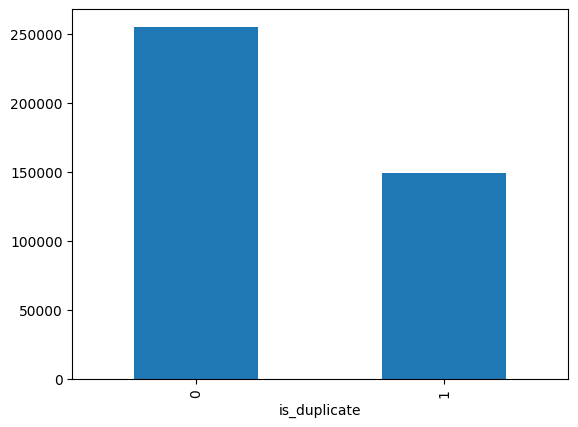

In [7]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts(normalize = True))
#print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')


#0 means the question is not a duplicate (unique question).
#1 means the question is a duplicate (repeated question).

In [8]:
#randomly selected 30000 rows as the dataset is huge
new_df=df.sample(30000, random_state=2)

In [9]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [10]:
def preprocess(q):
    
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset...so remove it
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')  #harcoded
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q) #grammar..dynamic
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    #contractions -- This is a dictionary that maps common contractions to their expanded forms.
    contractions = {     
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not","he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have","she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is","who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would","you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)   #join here is a method combines the words in the list q_decontracted into a single string, with spaces between them..
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
# Removing HTML tags...(e.g., <p> or <div> tags) to retain plain text.
#Uses the BeautifulSoup library.
    q = BeautifulSoup(q)
    q = q.get_text()
    
# Remove punctuations  and symbols using regular expressions..
#Ensures the cleaned text has only alphanumeric words separated by spaces....
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q
    

In [11]:
#Example
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [12]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

In [13]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


In [14]:
#feature engineering..created new features in dataset
#question 1 ----- char length of q1
#question 2 ----- char length of q2
#question 1 words ----- number of words in q1
#question 2 words ----- number of words in q2
#common words ---- number of common unique words in both questions
#words total --- total number of words in q1 + total number of words in q2
#word share --- word common / word total

# soo  for every row.. created seven new columns



#Feature engineering----Raw data may not capture all relevant patterns for the task.
#Engineering new features helps models understand relationships between inputs better, resulting in improved accuracy and predictions

In [15]:
#Feature engineering
#found length.. creates columns q1 and q2
new_df['q1_len'] = new_df['question1'].str.len() 
new_df['q2_len'] = new_df['question2'].str.len()

In [16]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()
#Split the questions on the basis of space...

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9


In [17]:
# create function.. pass the entire row..
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)
#set ..to remove duplicate words from list and give unique words..eg ['how','are',' you',' you']   will become ['how','are','you']

# & operator is used to find the intersection of the two sets... it gives the common words that appear in both question1 and question2...

In [18]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()
#new column called word_common got added
#eg--For the first row: question1 = "How are you?" and question2 = "How is it?", the common word is "how", so word_common = 1

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3


In [19]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))
# len(w1) gives the number of unique words in question1.
# len(w2) gives the number of unique words in question2.
# The function returns the sum of these lengths, which represents the total number of unique words across both questions.

In [20]:
new_df['word_total'] = new_df.apply(total_words, axis=1)  #axis=1 indicates row-wise operation
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1,34
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13


In [21]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
#The round() function is used to round the result to 2 decimal places.
new_df.head()
#word share gives a measure of how similar the two sentences are based on their shared vocabulary and its value ranges from 0 to 1

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24,0.33
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38,0.11
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1,34,0.03
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


In [22]:
#adding more features makes the model more accurate
#token features consists of tokens, words and stopwords..
#tokens are 3 in [i] [am] [vaishnavi]
#words are those except stopwords i.e., 2
#stopword is [am] which doesnt have any semantic meaning but are useful in sentence building
#cwc min --- ratio of number of common words to the length of smaller question  ----- no. of common words / min(words(q1,q2))
#cwc max  COMMON WORD COUNT   HOW MUCH THE LARGER QUESTION OVERLAPS THE SMALLER ONE
#csc min --- number of common stopwords / min(stopwords(q1,q2))
#csc max     COMMON STOPWORDS COUNT
#ctc min --- number of common tokens / min(tokens(q1,q2))
#ctc max    COMMON TOKENS COUNT
#last_word_eq --- last word should be equal in question
#first_word_eq
#---------------------------------------------------------------------------------------------------------------------------------------------------------
#length based features
#mean_len   -----  tokens(q1 + q2) / 2
#abs_len_diff ---  difference between tokens of q1 and q2         measure how unevenly the two questions are in length
#longest_substr_ratio   --- longest substring / min(token number(q1, q2))     how much of shared content (sequence) is there among the questions
#suppose q1  has w1 w2 w3 w4 w1 w2 --- token size is 6
#q2 has w1 w2 w5 w8 w1   --- token size is 5

#longest substring is w1 w2
# so 2/5
#---------------------------------------------------------------------------------------------------------------------------------------------------------
# Fuzzy features...Captures text similarity even when exact matches don't occur (e.g., "capital of India?" vs. "India's capital")
#fuzz_ratio
#fuzz_partial_ratio
#token_sort_ratio
#token_set_ratio

In [23]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001 # itializes a small constant value, SAFE_DIV, which will be used to avoid division by zero in calculations later in the function.

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
# Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:   #If either question is empty, it returns the token_features list with the initial values (0.0)
        return token_features

# Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
#Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
# Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
# Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
# Get the common Tokens from Question pair
#This calculates the total number of common tokens (both stopwords and non-stopwords)
#between q1_tokens and q2_tokens by finding the intersection of the two sets and getting its length.
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

#Below two lines calculate the ratio of common non-stopwords to the minimum and maximum number of non-stopwords between q1_words and q2_words.
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)

#These lines calculate the ratio of common stopwords to the minimum and maximum number of stopwords between q1_stops and q2_stops.
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)

#These lines calculate the ratio of common tokens (including stopwords) to the minimum and maximum number of tokens between q1_tokens and q2_tokens
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
# Last word of both question is same or not... so -1 ..since last word we must retrieve
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

# If they are the same, it assigns 1....  otherwise 0
# First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [24]:
#  applies the fetch_token_features function to each row, then extracts specific features from the results to create new columns in the DataFrame
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"]       = list(map(lambda x: x[0], token_features))
#above line of code.. extracts the first element (index 0) of each list in token_features and creates a new list with these values.. and then
# the resulting list is assigned to the new cwc_min column
new_df["cwc_max"]       = list(map(lambda x: x[1], token_features))
new_df["csc_min"]       = list(map(lambda x: x[2], token_features))
new_df["csc_max"]       = list(map(lambda x: x[3], token_features))
new_df["ctc_min"]       = list(map(lambda x: x[4], token_features))
new_df["ctc_max"]       = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [25]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,24,0.33,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,38,0.11,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,34,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749981,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0


In [26]:
#!pip install distance
import distance
#Length based features
def fetch_length_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    length_features = [0.0]*3
    
# Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:  #If either q1_tokens or q2_tokens is empty (i.e., the question is an empty string),
        #it immediately returns the length_features list with all zeros
        return length_features
    
# Absolute length features... difference between the number of tokens (words) in q1 and q2.
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
#Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

#Below lines of code..computes the longest common substrings between q1 and q2... returns a list of strings that are the common substrings.
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features
    

In [27]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [28]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.224490
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.047619
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.050847
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0,4.0,7.0,0.542857


In [29]:
# Fuzzy Features ---Captures text similarity even when exact matches don't occur (e.g., "capital of India?" vs. "India's capital").

#!pip install fuzzywuzzy
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0]*4
    
# fuzz_ratio--This function computes a standard similarity ratio between two strings
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

# fuzz_partial_ratio-------compares the strings but allows partial matches. It checks if one string is a substring of the other
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)  # (e.g., "apple pie" and "pie")

# token_sort_ratio --- This function splits q1, q2 into tokens, sorts the tokens alphabetically, and then compares the sorted tokens...
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)  # (e.g., "apple pie" and "pie apple" should have a high similarity).

# token_set_ratio --similar to token_sort_ratio... but it also removes duplicate tokens ........ 
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)  #(e.g., "apple apple pie" vs "apple pie").

    return fuzzy_features

In [30]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))


#Overall Flow:
#Step 1: fetch_fuzzy_features is applied to each row to get a tuple of fuzzy string
#          features (fuzz_ratio, fuzz_partial_ratio, token_sort_ratio, token_set_ratio).
#Step 2: The individual features are extracted from the tuples and stored in new columns
#         ('fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio') in new_df.

In [31]:
print(new_df.shape)
new_df.head()

(30000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [1]:
#Exploratory Data Analysis

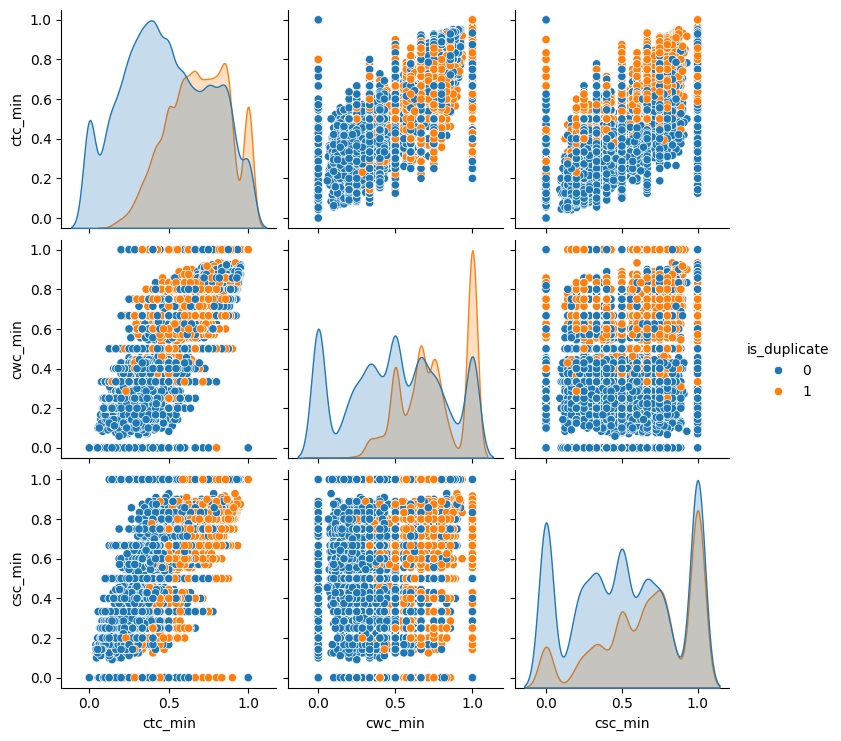

In [28]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

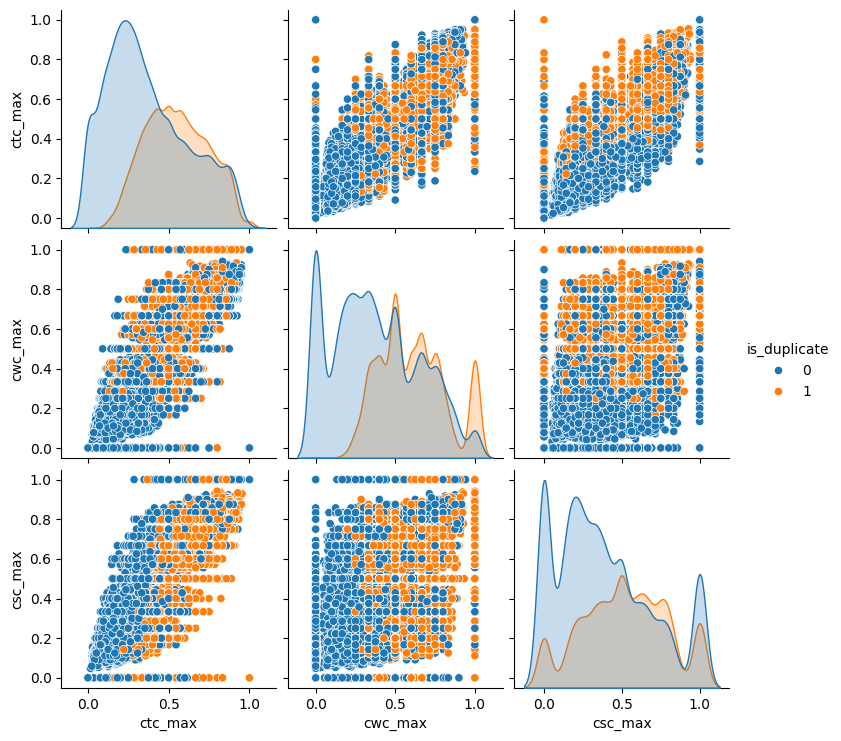

In [29]:
sns.pairplot(new_df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

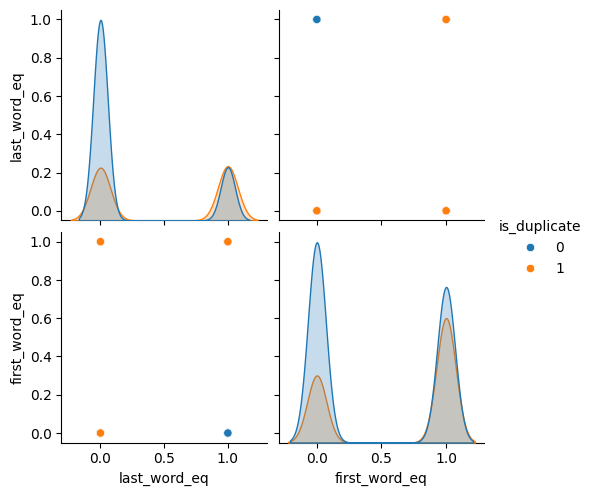

In [30]:
sns.pairplot(new_df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

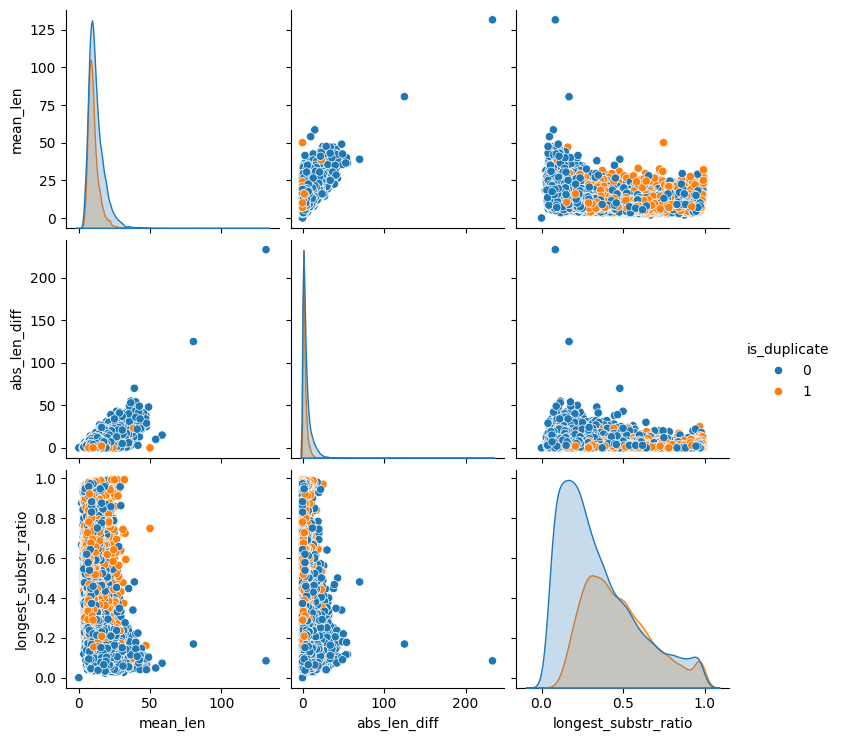

In [31]:
sns.pairplot(new_df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

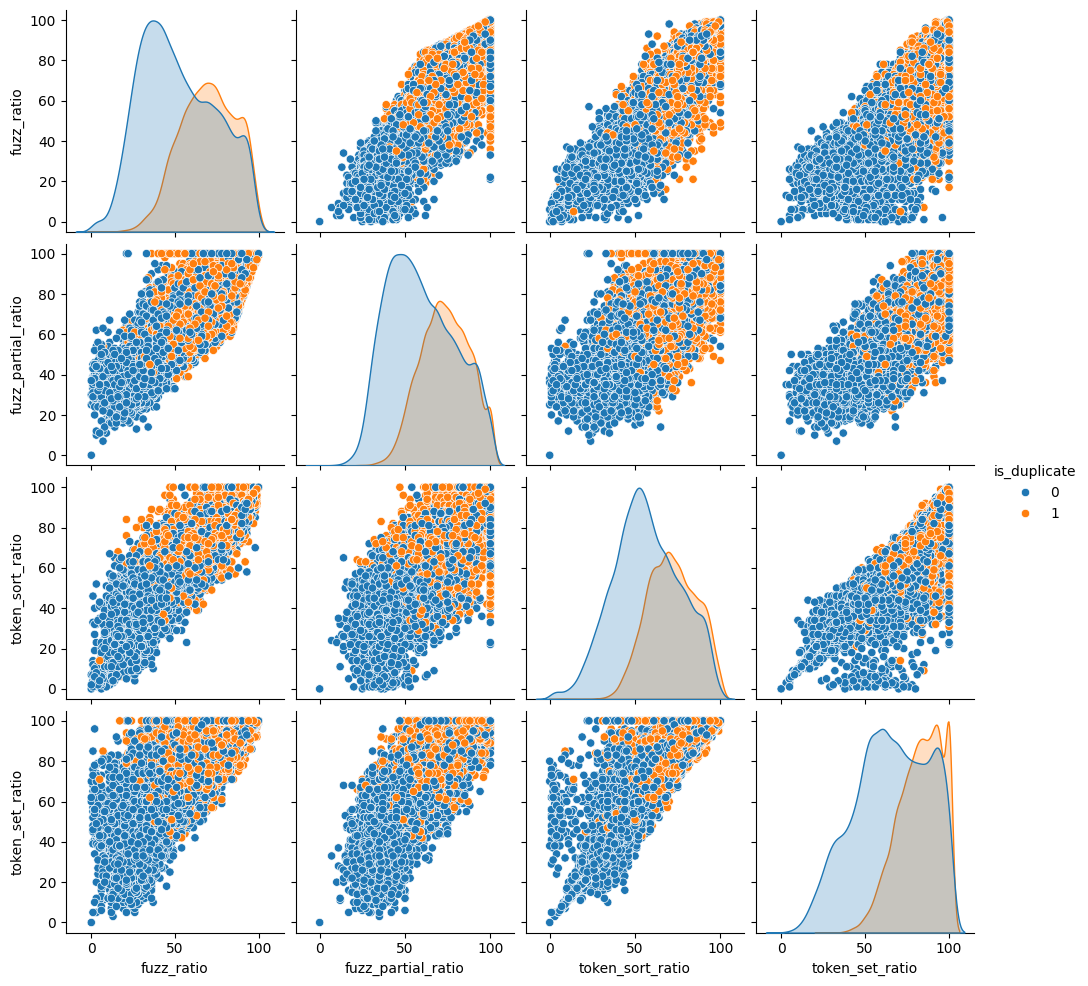

In [32]:
sns.pairplot(new_df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [33]:
# Using TSNE (t-Distributed Stochastic Neighbor Embedding) for Dimensionality reduction for 15 Features(Generated after cleaning the data) to 3 dimension

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(new_df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
# fit(): Computes the minimum and maximum values of each feature column.
# transform(): Scales each feature such that the values fall within the range of [0, 1].


y = new_df['is_duplicate'].values   #.values: This converts the column into a numpy array

In [34]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,  # reduce the data to 2 dimensions for visualization. 
    init='random', # initial points will be random
    random_state=101, #same random state + same result
    method='barnes_hut',   #calculates similarities between data points.
    n_iter=1000,   #number of iterations for the algorithm
    verbose=2,   #This level provides detailed logs showing more information about the fitting process,..like optimisation process
    angle=0.5   #The angle parameter controls the accuracy of the Barnes-Hut approximation..lower values means more accurate..
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.142s...
[t-SNE] Computed neighbors for 30000 samples in 9.762s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

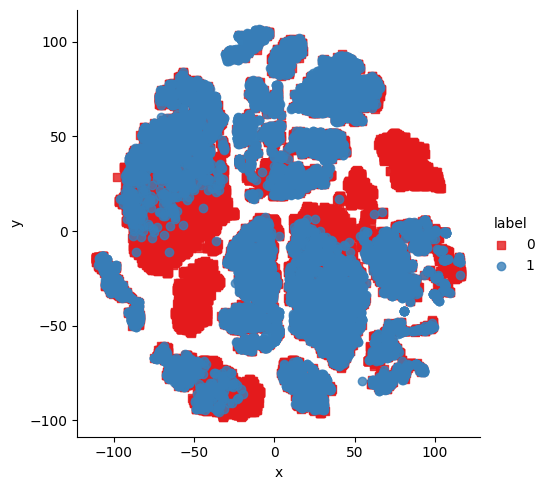

In [35]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False,palette="Set1",markers=['s','o'])

#fit_reg is false since tsne is non linear.. so we are not trying to fit a line generalize across all points

In [36]:
tsne3d = TSNE(
    n_components=3,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.179s...
[t-SNE] Computed neighbors for 30000 samples in 10.488s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sa

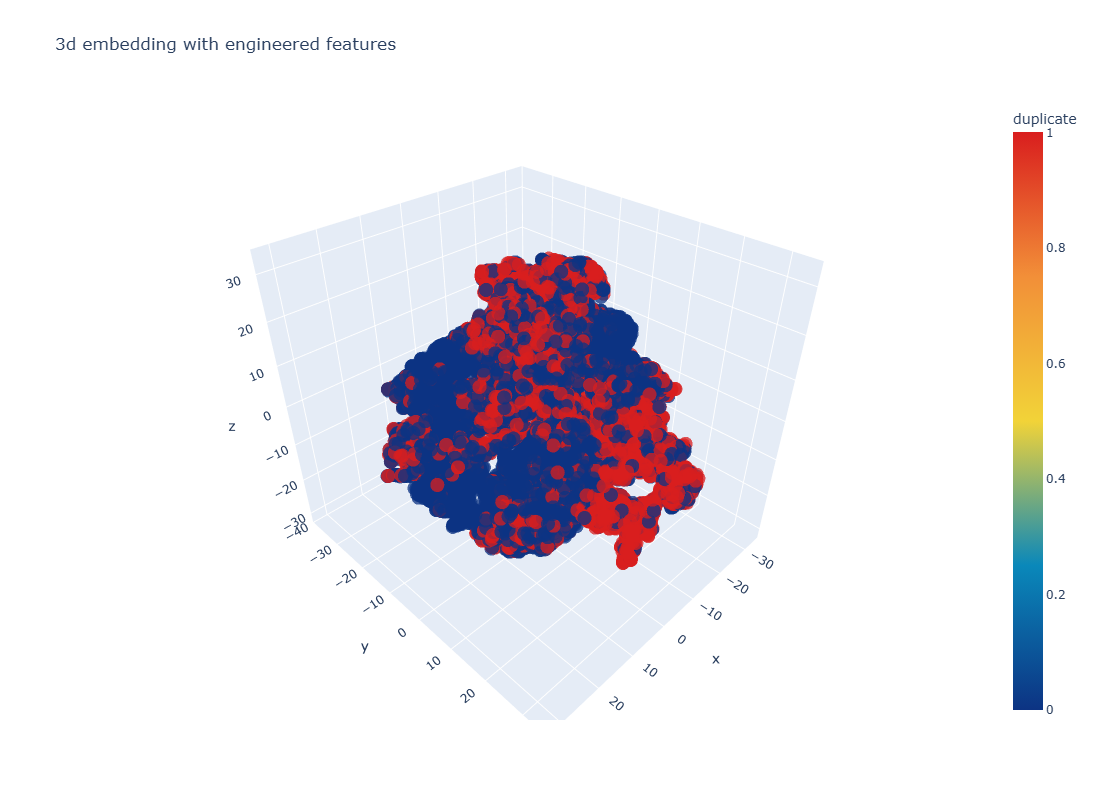

In [37]:
#!pip install plotly
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
py.init_notebook_mode(connected=True)

trace1 = go.Scatter3d(
    x=tsne3d[:,0],
    y=tsne3d[:,1],
    z=tsne3d[:,2],
    mode='markers',
    marker=dict(
        sizemode='diameter',
        color = y,
        colorscale = 'Portland',
        colorbar = dict(title = 'duplicate'),
        line=dict(color='rgb(255, 255, 255)'),
        opacity=0.75
    )
)

data=[trace1]
layout=dict(height=800, width=800, title='3d embedding with engineered features')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

In [32]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...
327711,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [33]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()




(30000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [34]:
"""#on question df.. bag of words
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)   #the vectorizer will only consider the top 3000 most frequent words from the entire dataset, 
                                         #based on the frequency of their occurrences...This is the core of the Bag of Words approach: 
                                         #counting the occurrence of words, disregarding the order in which they appear

#the result is a matrix where each row represents a question and each column represents one of the 3000 most frequent words..

q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)
#then converting it to an array for simpler processing...
"""



#!pip install scikit-learn


from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [35]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)

#index=ques_df.index: The index argument ensures that the index of the new DataFrame (temp_df2) matches the index of the original ques_df DataFrame
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [36]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()
#initial features came from advanced engineering, next 3000 features came from first question's bag of words, 
#next 3000 features came from second question's bag of words

(30000, 6023)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0,0,0,0,0,0,0,0,0,0
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0,0,0,0,0,0,0,0,0,0
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [37]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)


#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0].values,
                                                    #test_size=0.2, random_state=42)

In [44]:
"""from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)   #Making predictions
accuracy_score(y_test,y_pred)"""

'from sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score\nrf = RandomForestClassifier()\nrf.fit(X_train,y_train)\ny_pred = rf.predict(X_test)   #Making predictions\naccuracy_score(y_test,y_pred)'

In [45]:
#!pip install xgboost
"""
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test,y_pred1)"""

'\nfrom xgboost import XGBClassifier\nxgb = XGBClassifier()\nxgb.fit(X_train,y_train)\ny_pred1 = xgb.predict(X_test)\naccuracy_score(y_test,y_pred1)'

In [46]:
"""from sklearn.metrics import confusion_matrix
# for random forest model
confusion_matrix(y_test,y_pred)"""

'from sklearn.metrics import confusion_matrix\n# for random forest model\nconfusion_matrix(y_test,y_pred)'

In [47]:
"""# for xgboost model
confusion_matrix(y_test,y_pred1)"""

'# for xgboost model\nconfusion_matrix(y_test,y_pred1)'

In [38]:
def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return len(w1 & w2)

In [39]:
def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return (len(w1) + len(w2))

In [40]:
def test_fetch_token_features(q1,q2):
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [41]:
def test_fetch_length_features(q1,q2):
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [42]:
def test_fetch_fuzzy_features(q1,q2):
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [43]:
def query_point_creator(q1,q2):
#empty list create.. to store our 22 features
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    
    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))
    
    input_query.append(test_common_words(q1,q2))
    input_query.append(test_total_words(q1,q2))
    input_query.append(round(test_common_words(q1,q2)/test_total_words(q1,q2),2))
    
    # fetch token features
    token_features = test_fetch_token_features(q1,q2)
    input_query.extend(token_features)
    
    # fetch length based features
    length_features = test_fetch_length_features(q1,q2)
    input_query.extend(length_features)
    
    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()
    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [44]:
#q1 = 'Where is the capital of India?'
#q2 = 'What is the current capital of Pakistan?'
#q3 = 'Which city serves as the capital of India?'
#q4 = 'What is the business capital of India?'

In [35]:
#rf.predict(query_point_creator(q1,q4))

In [45]:
cv

CountVectorizer(max_features=3000)

In [58]:
#import pickle

#pickle.dump(rf,open('model.pkl','wb'))
#pickle.dump(cv,open('cv.pkl','wb'))

In [46]:
#Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:, 1:].values, final_df.iloc[:, 0].values, test_size=0.2, random_state=42)

# Initializing and training the Logistic Regression model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Making predictions on the test data
y_pred_logreg = logreg.predict(X_test)

# Calculating accuracy score
accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy Score: {accuracy}")

# Confusion Matrix for Logistic Regression model
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
print(f"Confusion Matrix:\n{conf_matrix_logreg}")


Accuracy Score: 0.7283333333333334
Confusion Matrix:
[[3073  726]
 [ 904 1297]]


In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0].values,
                                                    test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)   #Making predictions
accuracy_score(y_test,y_pred)






0.7883333333333333

In [48]:

#!pip install xgboost
#eXtreme Gradient Boosting
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test,y_pred1)


0.788

In [49]:
from sklearn.metrics import confusion_matrix
# for random forest model
confusion_matrix(y_test,y_pred)

array([[3267,  532],
       [ 738, 1463]])

In [50]:
# for xgboost model
confusion_matrix(y_test,y_pred1)

array([[3205,  594],
       [ 678, 1523]])

In [51]:
#so random forest or xgboost?
#accuracy of xgboost is high.. but when it comes to confusion matrix,..
#misclassications pose a risk..
#eg.: not really duplicate question pairs. but our model predicts it as duplicate..     is more risky
#eg.: was duplicate but it predicts not duplicate
#so the first possibility is problematic and spoils the user experience

#550 in case of random forest is |
              # predict
#actual
#     |  0       1
# 0   |  y       N  ---- this N must be less
# 1   |  N       Y

                 #predicted yes     predicted no
# actual yes          TP                  FP
#actual  no           FN                 TN
#Random forest makes that mistake less. so opt rf..

In [52]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'What is the business capital of India?'

In [53]:
rf.predict(query_point_creator(q1,q4))  #not same=0

array([0])

In [54]:
q5 = 'How did you first create wealth?'
q6 = 'How is wealth created?'
q7 = 'What is the purpose of life?'
q8 = 'Why is the purpose of life to "be happy"?'

In [55]:
rf.predict(query_point_creator(q5,q6))

array([0])

In [57]:
q9 = 'What course shall I do in USA after completing mba in India?'
q10 = 'What are the study options in USA after completing an MBA in marketing in India?'

In [59]:
rf.predict(query_point_creator(q9,q10))  #questions are similar

array([1])

In [61]:
rf.predict(query_point_creator( q7,q8 ))   #-----its not the same..but its showing that its the same

array([1])

In [63]:
q11 = "What's the stack of the search infrastructure team at Google?"
q12 = "Why is Google switching from MariaDB to MySQL?"

In [64]:
rf.predict(query_point_creator(q11, q12))

array([0])